In [1]:
import polars as pl

import polars_corpus as plc
import sentence_transformers

from sentence_transformers import SentenceTransformer
from sentence_transformers.sentence_transformer.modules import StaticEmbedding

from sklearn.cluster import AgglomerativeClustering, AffinityPropagation
from scipy.cluster import hierarchy

from sklearn.manifold import TSNE, MDS

import matplotlib.pyplot as plt

import umap

from adjustText import adjust_text
from polars_corpus.utils import (
    as_corpus,
    as_expr,
    check_choice,
    check_columns,
    check_expr,
    collect_like,
    drop_null_rows,
)

import hdbscan

In [2]:
pl.Config.set_fmt_str_lengths(500)
pl.Config.set_fmt_table_cell_list_len(100)
pl.Config.set_tbl_rows(30)

polars.config.Config

In [3]:
bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

In [45]:
k = (
    plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ttest',
    expr=pl.col('lemma').str.to_lowercase()
).sort(by='stat', descending=True).head(200)).collect()

In [46]:
emb = StaticEmbedding.from_model2vec("minishlab/potion-base-32M")
#emb = StaticEmbedding.from_model2vec("minishlab/M2V_base_glove")

model = SentenceTransformer(modules=[emb])


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

In [47]:
k = k.with_columns(emb=plc.encode(model, "lemma"))

In [48]:
k.schema

Schema([('lemma', String),
        ('stat', Float64),
        ('pval', Float64),
        ('df', Float64),
        ('emb', Array(Float32, shape=(512,)))])

In [49]:
k = k.with_columns(cluster=AffinityPropagation(verbose=True).fit_predict(k['emb']))
k.group_by("cluster").agg(words=pl.col("lemma").str.join(' '))

Converged after 47 iterations.


cluster,words
i64,str
10,"""week wednesday weekend"""
33,"""orange dye colour"""
18,"""child wooden grandson family keith"""
17,"""lounge bedroom tired night overnight tonight late"""
31,"""to whether because then when"""
12,"""else peculiar pale surprise alter"""
3,"""shopping visit knitting shop"""
6,"""she husband hers mrs margaret liz pam catherine diane deb elizabeth school"""
25,"""treatment packet dose"""


In [50]:
k = k.with_columns(cluster=hdbscan.HDBSCAN(min_cluster_size=3,min_samples=1).fit_predict(k['emb'].to_numpy()))
k.sort(by='cluster').group_by("cluster").agg(words=pl.col("lemma").str.join(', '))

cluster,words
i64,str
-1,"""to, child, goodness, forget, cos, alice, help, have, oh, selfish, visit, else, hall, lounge, bedroom, and, pet, treatment, moody, settee, knitting, pepper, mouthful, jumper, roller, dream, mm, comb, such, pile, maureen, packet, summer, pale, wooden, funeral, just, respond, grandson, mug, warm, come, hope, solve, frog, arthur, sponge, leaf, keith, ross, mo, calory, collect, dose, deb, grate, commission, nature, runny, then, pantomime, gerry, browny, late, raising, die, school, chocolate, porter, …"
0,"""muddle, thaw, snowdrop"""
1,"""whether, because, when"""
2,"""waste, toilet, rot, bathroom"""
3,"""think, mind, mental"""
4,"""belong, attach, invitation"""
5,"""orange, dye, colour"""
6,"""hide, keen, tight, confidential, leave"""
7,"""vegetable, cooking, kitchen, feed, casserole, cook, meal, pork, biscuit, sandwich, celery"""


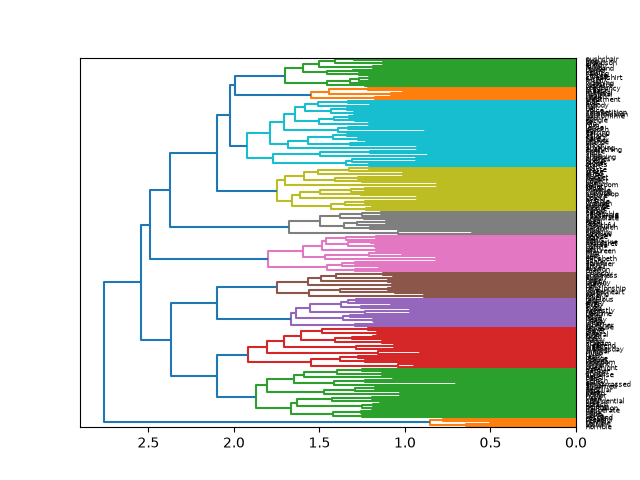

In [51]:
Z = hierarchy.linkage(k['emb'], method="ward")
plt.figure()
hierarchy.dendrogram(Z, orientation="left", labels=k['lemma'])
plt.show()

In [52]:
xy = TSNE(2).fit_transform(k['emb'])
fig, ax = plt.subplots(figsize=(8,8))
plc.text_plot(xy, k['lemma'], adjust=True, ax=ax)

<Axes: >

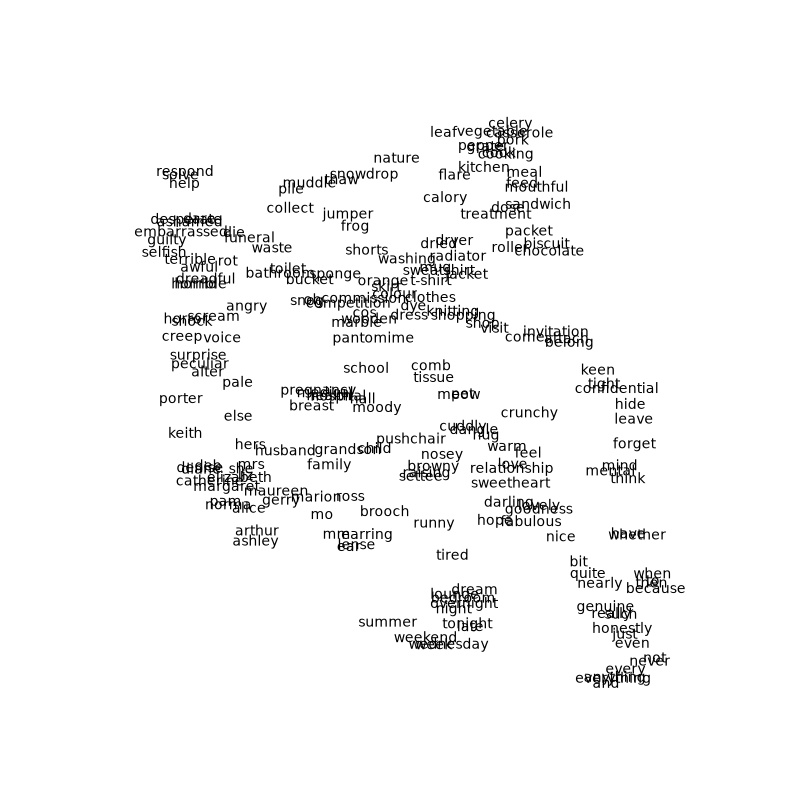

In [53]:
xy = umap.UMAP(n_neighbors=5,n_components=2,init='pca').fit_transform(k['emb'])
fig, ax = plt.subplots(figsize=(8,8))
plc.text_plot(xy, k['lemma'], adjust=False, ax=ax, show_labels=True, hover=True)
plt.show()

In [54]:
xy = umap.UMAP(n_neighbors=5,n_components=100,init='pca').fit_transform(k['emb'])
k = k.with_columns(cluster=hdbscan.HDBSCAN(min_cluster_size=5,min_samples=1).fit_predict(xy))
k.sort(by='cluster').group_by("cluster").agg(words=pl.col("lemma").str.join(', '))

cluster,words
i64,str
-1,"""feel, goodness, help, oh, else, pet, comb, maureen, respond, warm, hope, solve, keith, orange, dye, gerry, voice, porter, radiator, meow, crunchy, tissue, colour, snog"""
0,"""lounge, bedroom, week, wednesday, dream, tired, summer, weekend, night, overnight, tonight, runny, late"""
1,"""vegetable, cooking, kitchen, feed, casserole, treatment, cook, meal, pepper, mouthful, roller, packet, pork, biscuit, leaf, calory, dose, grate, sandwich, chocolate, flare, celery"""
2,"""hospital, hall, moody, breast, health, pregnancy, school, medical"""
3,"""skirt, cos, shopping, visit, knitting, jumper, dress, wooden, mug, come, frog, shorts, clothes, jacket, commission, washing, t-shirt, pantomime, dryer, dried, competition, shop, marble, sweatshirt"""
4,"""waste, pile, toilet, rot, sponge, muddle, collect, nature, bathroom, thaw, bucket, snowdrop"""
5,"""earring, ear, mm, ross, mo, brooch, lense, marion"""
6,"""think, belong, forget, whether, have, hide, mind, keen, tight, attach, confidential, mental, invitation, leave"""
7,"""lovely, love, darling, nice, sweetheart, bit, relationship, fabulous"""


In [34]:
%matplotlib widget
